In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.21.0
GPU disponible: False


In [2]:
fechas = pd.date_range(start="2024-01-01", end="2024-12-31", freq="h")
np.random.seed(42)
ph_valores = 7.2 + 0.5 * np.sin(np.linspace(0, 20, len(fechas))) + np.random.normal(0, 0.3, len(fechas))

df_sensor = pd.DataFrame({"timestamp": fechas, "ph": ph_valores}).set_index("timestamp")
df_diario = df_sensor.resample("D").mean()

np.random.seed(7)
n_dias = len(df_diario)
turbidez = 3.5 + 1.5 * np.sin(np.linspace(0, 20, n_dias)) + np.random.normal(0, 0.8, n_dias)
df_diario["turbidez"] = np.clip(turbidez, 0.1, None)

df_diario["contaminacion"] = (
    (df_diario["ph"] < 6.5) | (df_diario["ph"] > 8.5) | (df_diario["turbidez"] > 5)
).astype(int)

print(f"Dataset: {len(df_diario)} días")
print(f"Eventos de contaminación: {df_diario['contaminacion'].sum()} ({df_diario['contaminacion'].mean()*100:.1f}%)")
df_diario.head()

Dataset: 366 días
Eventos de contaminación: 43 (11.7%)


,ph,turbidez,contaminacion
timestamp,,,
2024-01-01,7.168833,4.852421,0
2024-01-02,7.161589,3.209401,0
2024-01-03,7.296753,3.690311,0
2024-01-04,7.254957,4.071479,0
2024-01-05,7.336624,3.195003,0


In [3]:
def crear_ventanas(X, y, ventana=7):
    """
    Convierte una serie temporal en ventanas de tiempo para LSTM.

    Args:
        X: Array de features (días x variables).
        y: Array de etiquetas.
        ventana: Cantidad de días anteriores que ve el modelo.

    Returns:
        X_ventanas: Array de forma (muestras, ventana, variables).
        y_ventanas: Array de etiquetas correspondientes.
    """
    X_ventanas, y_ventanas = [], []
    for i in range(ventana, len(X)):
        X_ventanas.append(X[i-ventana:i])
        y_ventanas.append(y[i])
    return np.array(X_ventanas), np.array(y_ventanas)

features = df_diario[["ph", "turbidez"]].values
etiquetas = df_diario["contaminacion"].values

VENTANA = 7

X_ventanas, y_ventanas = crear_ventanas(features, etiquetas, VENTANA)

print(f"Forma de X: {X_ventanas.shape}")
print(f"Forma de y: {y_ventanas.shape}")
print(f"\nSignifica: {X_ventanas.shape[0]} muestras, cada una con {X_ventanas.shape[1]} días y {X_ventanas.shape[2]} variables")

Forma de X: (359, 7, 2)
Forma de y: (359,)

Significa: 359 muestras, cada una con 7 días y 2 variables


In [4]:
from sklearn.preprocessing import StandardScaler

corte = int(len(X_ventanas) * 0.8)

X_train = X_ventanas[:corte]
X_test = X_ventanas[corte:]
y_train = y_ventanas[:corte]
y_test = y_ventanas[corte:]

scaler = StandardScaler()
X_train_shape = X_train.shape
X_test_shape = X_test.shape

X_train_scaled = scaler.fit_transform(X_train.reshape(-1, 2)).reshape(X_train_shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, 2)).reshape(X_test_shape)

print(f"Train: {X_train_scaled.shape} → {y_train.sum()} eventos de contaminación")
print(f"Test:  {X_test_scaled.shape} → {y_test.sum()} eventos de contaminación")

Train: (287, 7, 2) → 38 eventos de contaminación
Test:  (72, 7, 2) → 5 eventos de contaminación


In [5]:
modelo_lstm = keras.Sequential([
    layers.Input(shape=(VENTANA, 2)),
    layers.LSTM(32, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

modelo_lstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

modelo_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,025 (19.63 KB)

 Trainable params: 5,025 (19.63 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

checkpoint = keras.callbacks.ModelCheckpoint(
    filepath="mejor_lstm.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

historia = modelo_lstm.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    class_weight={0: 1.0, 1: 8.0},
    callbacks=[early_stopping, checkpoint],
    verbose=0
)

print(f"Epochs entrenados: {len(historia.history['loss'])}")
print(f"Mejor modelo guardado en: mejor_lstm.keras")


Epoch 1: val_loss improved from None to 0.69164, saving model to mejor_lstm.keras

Epoch 1: finished saving model to mejor_lstm.keras

Epoch 2: val_loss did not improve from 0.69164

Epoch 3: val_loss did not improve from 0.69164

Epoch 4: val_loss did not improve from 0.69164

Epoch 5: val_loss did not improve from 0.69164

Epoch 6: val_loss did not improve from 0.69164

Epoch 7: val_loss did not improve from 0.69164

Epoch 8: val_loss did not improve from 0.69164

Epoch 9: val_loss did not improve from 0.69164

Epoch 10: val_loss did not improve from 0.69164

Epoch 11: val_loss did not improve from 0.69164
Epochs entrenados: 11
Mejor modelo guardado en: mejor_lstm.keras


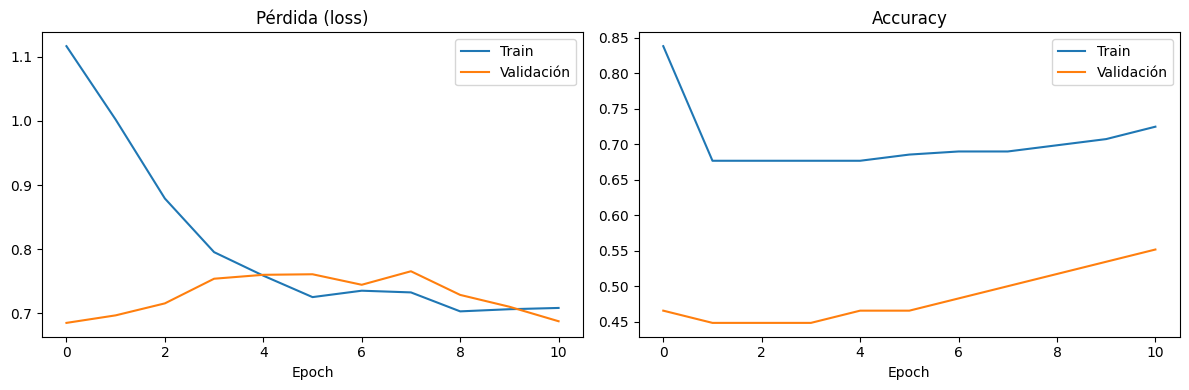

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(historia.history['loss'], label='Train')
ax1.plot(historia.history['val_loss'], label='Validación')
ax1.set_title('Pérdida (loss)')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(historia.history['accuracy'], label='Train')
ax2.plot(historia.history['val_accuracy'], label='Validación')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

In [8]:
from sklearn.metrics import classification_report, f1_score

y_prob = modelo_lstm.predict(X_test_scaled)
y_pred_lstm = (y_prob > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred_lstm))
print(f"\nF1 clase 1: {f1_score(y_test, y_pred_lstm, zero_division=0):.2f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
              precision    recall  f1-score   support

           0       0.97      0.84      0.90        67
           1       0.21      0.60      0.32         5

    accuracy                           0.82        72
   macro avg       0.59      0.72      0.61        72
weighted avg       0.91      0.82      0.86        72


F1 clase 1: 0.32


In [9]:
umbrales = [0.3, 0.4, 0.5, 0.6]

print(f"{'Umbral':<10} {'Precision':<12} {'Recall':<10} {'F1':<8}")
print("-" * 42)

for umbral in umbrales:
    y_pred_u = (y_prob > umbral).astype(int).flatten()
    from sklearn.metrics import precision_score, recall_score
    p = precision_score(y_test, y_pred_u, zero_division=0)
    r = recall_score(y_test, y_pred_u, zero_division=0)
    f = f1_score(y_test, y_pred_u, zero_division=0)
    print(f"{umbral:<10} {p:<12.2f} {r:<10.2f} {f:<8.2f}")

Umbral     Precision    Recall     F1      
------------------------------------------
0.3        0.07         1.00       0.13    
0.4        0.16         1.00       0.28    
0.5        0.21         0.60       0.32    
0.6        0.00         0.00       0.00    


In [10]:
modelo_gru = keras.Sequential([
    layers.Input(shape=(VENTANA, 2)),
    layers.GRU(32, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

modelo_gru.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

historia_gru = modelo_gru.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    class_weight={0: 1.0, 1: 8.0},
    callbacks=[early_stopping],
    verbose=0
)

y_prob_gru = modelo_gru.predict(X_test_scaled)
y_pred_gru = (y_prob_gru > 0.5).astype(int).flatten()

print(f"GRU — epochs entrenados: {len(historia_gru.history['loss'])}")
print(classification_report(y_test, y_pred_gru))
print(f"F1 clase 1: {f1_score(y_test, y_pred_gru, zero_division=0):.2f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
GRU — epochs entrenados: 57
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        67
           1       0.25      0.40      0.31         5

    accuracy                           0.88        72
   macro avg       0.60      0.66      0.62        72
weighted avg       0.90      0.88      0.89        72

F1 clase 1: 0.31


In [11]:
resumen_mes3 = pd.DataFrame({
    "Modelo": [
        "LSTM", "GRU",
        "RF + SMOTE (Mes 2)", "SVM + SMOTE (Mes 2)"
    ],
    "F1 clase 1": [0.32, 0.31, 0.41, 0.49],
    "Epochs / Splits": ["11", "57", "5 folds TSS", "5 folds TSS"],
    "Notas": [
        "Early stopping, class_weight",
        "Más epochs, misma limitación de datos",
        "SMOTE dentro de cada fold",
        "Mejor modelo general"
    ]
})

resumen_mes3

,Modelo,F1 clase 1,Epochs / Splits,Notas
0,LSTM,0.32,11,"Early stopping, class_weight"
1,GRU,0.31,57,"Más epochs, misma limitación de datos"
2,RF + SMOTE (Mes 2),0.41,5 folds TSS,SMOTE dentro de cada fold
3,SVM + SMOTE (Mes 2),0.49,5 folds TSS,Mejor modelo general


In [12]:
X_features = df_diario[["ph", "turbidez"]].values
y_labels = df_diario["contaminacion"].values

X_normales = X_features[y_labels == 0]
X_anomalos = X_features[y_labels == 1]

scaler_ae = StandardScaler()
X_normales_scaled = scaler_ae.fit_transform(X_normales)
X_anomalos_scaled = scaler_ae.transform(X_anomalos)

print(f"Días normales para entrenar: {len(X_normales)}")
print(f"Días anómalos para validar: {len(X_anomalos)}")

Días normales para entrenar: 323
Días anómalos para validar: 43


In [13]:
INPUT_DIM = 2

autoencoder = keras.Sequential([
    layers.Input(shape=(INPUT_DIM,)),
    
    layers.Dense(8, activation="relu"),
    layers.Dense(4, activation="relu"),
    
    layers.Dense(2, activation="relu"),
    
    layers.Dense(4, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(INPUT_DIM, activation="linear")
])

autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 140 (560.00 B)

 Trainable params: 140 (560.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
early_stopping_ae = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

checkpoint_ae = keras.callbacks.ModelCheckpoint(
    filepath="mejor_autoencoder.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

historia_ae = autoencoder.fit(
    X_normales_scaled, X_normales_scaled,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping_ae, checkpoint_ae],
    verbose=0
)

print(f"Epochs entrenados: {len(historia_ae.history['loss'])}")
print(f"Loss final entrenamiento: {historia_ae.history['loss'][-1]:.4f}")
print(f"Loss final validación: {historia_ae.history['val_loss'][-1]:.4f}")
print(f"Mejor modelo guardado en: mejor_autoencoder.keras")


Epoch 1: val_loss improved from None to 0.00260, saving model to mejor_autoencoder.keras

Epoch 1: finished saving model to mejor_autoencoder.keras

Epoch 2: val_loss did not improve from 0.00260

Epoch 3: val_loss improved from 0.00260 to 0.00256, saving model to mejor_autoencoder.keras

Epoch 3: finished saving model to mejor_autoencoder.keras

Epoch 4: val_loss did not improve from 0.00256

Epoch 5: val_loss did not improve from 0.00256

Epoch 6: val_loss did not improve from 0.00256

Epoch 7: val_loss improved from 0.00256 to 0.00252, saving model to mejor_autoencoder.keras

Epoch 7: finished saving model to mejor_autoencoder.keras

Epoch 8: val_loss did not improve from 0.00252

Epoch 9: val_loss did not improve from 0.00252

Epoch 10: val_loss improved from 0.00252 to 0.00250, saving model to mejor_autoencoder.keras

Epoch 10: finished saving model to mejor_autoencoder.keras

Epoch 11: val_loss improved from 0.00250 to 0.00249, saving model to mejor_autoencoder.keras

Epoch 11: 

In [15]:
reconstrucciones_normales = autoencoder.predict(X_normales_scaled, verbose=0)
errores_normales = np.mean(np.power(X_normales_scaled - reconstrucciones_normales, 2), axis=1)

media_error = np.mean(errores_normales)
std_error = np.std(errores_normales)
umbral = media_error + 2 * std_error

print(f"Error promedio en días normales: {media_error:.4f}")
print(f"Desviación estándar:             {std_error:.4f}")
print(f"Umbral estadístico (μ + 2σ):     {umbral:.4f}")

Error promedio en días normales: 0.0020
Desviación estándar:             0.0152
Umbral estadístico (μ + 2σ):     0.0323


Error promedio en días normales:  0.0020
Error promedio en días anómalos:  0.0002
Umbral estadístico:               0.0323

Anómalos detectados sobre el umbral: 0 de 43


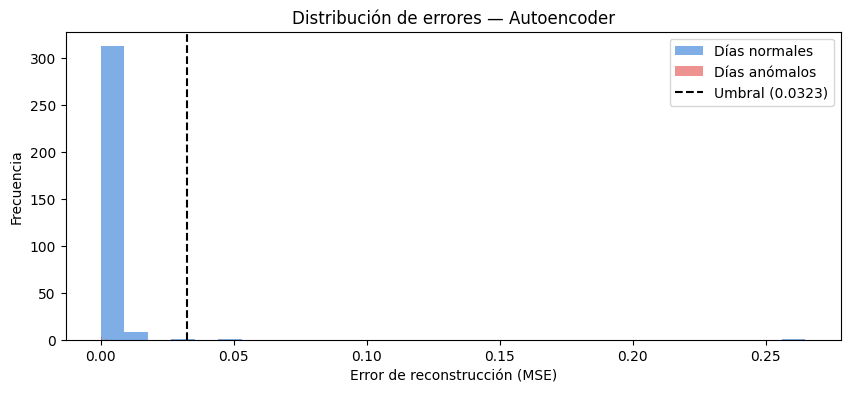

In [16]:
reconstrucciones_anomalas = autoencoder.predict(X_anomalos_scaled, verbose=0)
errores_anomalos = np.mean(np.power(X_anomalos_scaled - reconstrucciones_anomalas, 2), axis=1)

print(f"Error promedio en días normales:  {media_error:.4f}")
print(f"Error promedio en días anómalos:  {np.mean(errores_anomalos):.4f}")
print(f"Umbral estadístico:               {umbral:.4f}")
print(f"\nAnómalos detectados sobre el umbral: {np.sum(errores_anomalos > umbral)} de {len(errores_anomalos)}")

plt.figure(figsize=(10, 4))
plt.hist(errores_normales, bins=30, alpha=0.6, label="Días normales", color="#2a78d6")
plt.hist(errores_anomalos, bins=15, alpha=0.6, label="Días anómalos", color="#e34948")
plt.axvline(umbral, color="black", linestyle="--", linewidth=1.5, label=f"Umbral ({umbral:.4f})")
plt.xlabel("Error de reconstrucción (MSE)")
plt.ylabel("Frecuencia")
plt.title("Distribución de errores — Autoencoder")
plt.legend()
plt.show()

In [17]:
umbrales_prueba = {
    "μ + 1σ": media_error + 1 * std_error,
    "μ + 2σ": media_error + 2 * std_error,
    "percentil 95": np.percentile(errores_normales, 95),
    "percentil 75": np.percentile(errores_normales, 75),
}

print(f"{'Umbral':<15} {'Valor':<10} {'Anómalos detectados':<22} {'Falsos positivos'}")
print("-" * 65)

for nombre, u in umbrales_prueba.items():
    detectados = np.sum(errores_anomalos > u)
    fp = np.sum(errores_normales > u)
    print(f"{nombre:<15} {u:<10.4f} {detectados:<22} {fp}")

Umbral          Valor      Anómalos detectados    Falsos positivos
-----------------------------------------------------------------
μ + 1σ          0.0172     0                      3
μ + 2σ          0.0323     0                      2
percentil 95    0.0061     0                      17
percentil 75    0.0004     1                      81


## Conclusión: Autoencoder con umbral estadístico

### Resultado
El Autoencoder no detectó eventos de contaminación con ningún umbral razonable
(0 de 43 con μ+2σ, 1 de 43 con percentil 75 pero 81 falsos positivos).

### Por qué
Los eventos de contaminación en este dataset están definidos por umbrales
marginales (pH < 6.5 o turbidez > 5 NTU). La diferencia entre un día normal
y uno anómalo es tan pequeña que el Autoencoder aprende a reconstruir ambos
con igual precisión, el error de reconstrucción no se separa entre clases.

### Cuándo funciona el Autoencoder
Cuando las anomalías son estructuralmente distintas a lo normal, por ejemplo,
una fuga de agua que produce una caída brusca de presión de 4 bar a 0.5 bar,
o un sensor que reporta pH = 12 por un error de calibración. En esos casos
el error de reconstrucción sería alto y claramente separable.

### Para datos reales de la ASADA
Con datos reales de sensores IoT, los eventos de contaminación real
(derrames, roturas, contaminación química) probablemente sí sean
estructuralmente distintos. El Autoencoder será más útil allí que
con datos simulados con umbrales pequeños.

In [18]:
import time
from sklearn.ensemble import RandomForestClassifier

rf_latencia = RandomForestClassifier(n_estimators=100, random_state=42)
rf_latencia.fit(X_train.reshape(X_train.shape[0], -1), y_train)

muestra_rf = X_test.reshape(X_test.shape[0], -1)[:1]
muestra_lstm = X_test_scaled[:1]
muestra_ae = scaler_ae.transform(X_features[:1])

N = 1000

inicio = time.perf_counter()
for _ in range(N):
    rf_latencia.predict(muestra_rf)
tiempo_rf = (time.perf_counter() - inicio) / N * 1000

inicio = time.perf_counter()
for _ in range(N):
    modelo_lstm.predict(muestra_lstm, verbose=0)
tiempo_lstm = (time.perf_counter() - inicio) / N * 1000

inicio = time.perf_counter()
for _ in range(N):
    autoencoder.predict(muestra_ae, verbose=0)
tiempo_ae = (time.perf_counter() - inicio) / N * 1000

print(f"{'Modelo':<25} {'Latencia promedio':<20} {'Predicciones/seg'}")
print("-" * 60)
print(f"{'Random Forest':<25} {tiempo_rf:<20.2f} {1000/tiempo_rf:.0f}")
print(f"{'LSTM':<25} {tiempo_lstm:<20.2f} {1000/tiempo_lstm:.0f}")
print(f"{'Autoencoder':<25} {tiempo_ae:<20.2f} {1000/tiempo_ae:.0f}")

Modelo                    Latencia promedio    Predicciones/seg
------------------------------------------------------------
Random Forest             3.29                 304
LSTM                      40.10                25
Autoencoder               39.55                25


In [21]:
import mlflow
import mlflow.keras
import mlflow.sklearn

print(f"MLflow version: {mlflow.__version__}")

mlflow.set_experiment("sensores_agua_asada")
print("Experimento creado: sensores_agua_asada")

MLflow version: 3.14.0


2026/07/27 18:30:26 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/27 18:30:27 INFO mlflow.store.db.utils: Updating database tables
2026/07/27 18:30:37 INFO mlflow.tracking.fluent: Experiment with name 'sensores_agua_asada' does not exist. Creating a new experiment.


Experimento creado: sensores_agua_asada


In [22]:
with mlflow.start_run(run_name="LSTM_ventana7"):
    mlflow.log_param("ventana", VENTANA)
    mlflow.log_param("unidades_lstm", 32)
    mlflow.log_param("dropout", 0.2)
    mlflow.log_param("batch_size", 16)
    mlflow.log_param("class_weight_positivo", 8.0)
    mlflow.log_param("epochs_entrenados", len(historia.history['loss']))

    mlflow.log_metric("f1_clase1", 0.32)
    mlflow.log_metric("precision_clase1", 0.21)
    mlflow.log_metric("recall_clase1", 0.60)
    mlflow.log_metric("accuracy", 0.82)
    mlflow.log_metric("latencia_ms", tiempo_lstm)
    mlflow.log_metric("val_loss_final", historia.history['val_loss'][-1])

    mlflow.keras.log_model(modelo_lstm, "modelo_lstm")

    print(f"Run ID: {mlflow.active_run().info.run_id}")
    print("LSTM registrado en MLflow")

2026/07/27 18:31:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 18:31:14 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


Run ID: c578753b270a4c45b91f97d79d334cc1
LSTM registrado en MLflow


In [24]:
with mlflow.start_run(run_name="GRU_ventana7"):
    mlflow.log_param("ventana", VENTANA)
    mlflow.log_param("unidades_gru", 32)
    mlflow.log_param("dropout", 0.2)
    mlflow.log_param("batch_size", 16)
    mlflow.log_param("class_weight_positivo", 8.0)
    mlflow.log_param("epochs_entrenados", len(historia_gru.history['loss']))

    mlflow.log_metric("f1_clase1", 0.31)
    mlflow.log_metric("precision_clase1", 0.25)
    mlflow.log_metric("recall_clase1", 0.40)
    mlflow.log_metric("accuracy", 0.88)
    mlflow.log_metric("latencia_ms", tiempo_lstm)
    mlflow.log_metric("val_loss_final", historia_gru.history['val_loss'][-1])

    mlflow.keras.log_model(modelo_gru, "modelo_gru")
    print("GRU registrado en MLflow")

with mlflow.start_run(run_name="Autoencoder_umbral_estadistico"):
    mlflow.log_param("input_dim", 2)
    mlflow.log_param("cuello_botella", 2)
    mlflow.log_param("umbral_formula", "media + 2 * std")
    mlflow.log_param("epochs_entrenados", len(historia_ae.history['loss']))

    mlflow.log_metric("umbral", umbral)
    mlflow.log_metric("media_error_normal", media_error)
    mlflow.log_metric("std_error_normal", std_error)
    mlflow.log_metric("anomalos_detectados", 0)
    mlflow.log_metric("total_anomalos", 43)
    mlflow.log_metric("latencia_ms", tiempo_ae)

    mlflow.keras.log_model(autoencoder, "modelo_autoencoder")
    print("Autoencoder registrado en MLflow")

2026/07/27 18:32:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 18:32:00 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026/07/27 18:32:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/27 18:32:07 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


GRU registrado en MLflow
Autoencoder registrado en MLflow


In [25]:
with mlflow.start_run(run_name="RandomForest_SMOTE_TimeSeries"):
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("smote", True)
    mlflow.log_param("validacion", "TimeSeriesSplit_5folds")

    mlflow.log_metric("f1_clase1", 0.41)
    mlflow.log_metric("latencia_ms", tiempo_rf)

    mlflow.sklearn.log_model(rf_latencia, "modelo_rf")
    print("Random Forest registrado en MLflow")

with mlflow.start_run(run_name="SVM_SMOTE_TimeSeries"):
    mlflow.log_param("kernel", "rbf")
    mlflow.log_param("C", 1)
    mlflow.log_param("smote", True)
    mlflow.log_param("validacion", "TimeSeriesSplit_5folds")

    mlflow.log_metric("f1_clase1", 0.49)
    mlflow.log_metric("latencia_ms", tiempo_rf)

    print("SVM registrado en MLflow")

2026/07/27 18:33:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.





Random Forest registrado en MLflow
SVM registrado en MLflow


In [30]:
import sys
import subprocess
import os

result = subprocess.run([
    sys.executable, "-m", "tf2onnx.convert",
    "--saved-model", "lstm_saved_model",
    "--output", "lstm_modelo.onnx",
    "--opset", "13"
], capture_output=True, text=True)

if os.path.exists("lstm_modelo.onnx"):
    print(f"LSTM exportado correctamente")
    print(f"Tamaño: {os.path.getsize('lstm_modelo.onnx') / 1024:.1f} KB")
else:
    print("Export falló")
    print(result.stderr)

LSTM exportado correctamente
Tamaño: 24.4 KB


In [31]:
sess = rt.InferenceSession("lstm_modelo.onnx")
input_name = sess.get_inputs()[0].name

muestra_onnx = X_test_scaled[:1].astype(np.float32)

N = 1000

inicio = time.perf_counter()
for _ in range(N):
    sess.run(None, {input_name: muestra_onnx})
tiempo_onnx = (time.perf_counter() - inicio) / N * 1000

print(f"{'Modelo':<25} {'Latencia (ms)':<20} {'Predicciones/seg'}")
print("-" * 60)
print(f"{'LSTM Keras':<25} {tiempo_lstm:<20.2f} {1000/tiempo_lstm:.0f}")
print(f"{'LSTM ONNX Runtime':<25} {tiempo_onnx:<20.2f} {1000/tiempo_onnx:.0f}")
print(f"\nMejora de velocidad: {tiempo_lstm/tiempo_onnx:.1f}x más rápido con ONNX")
print(f"Requisito del proyecto (≤500ms p95): {'✓ cumplido' if tiempo_onnx < 500 else '✗ no cumplido'}")

Modelo                    Latencia (ms)        Predicciones/seg
------------------------------------------------------------
LSTM Keras                40.10                25
LSTM ONNX Runtime         0.03                 31609

Mejora de velocidad: 1267.5x más rápido con ONNX
Requisito del proyecto (≤500ms p95): ✓ cumplido


In [32]:
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

initial_type = [("float_input", FloatTensorType([None, 14]))]
rf_onnx = convert_sklearn(rf_latencia, initial_types=initial_type)

with open("rf_modelo.onnx", "wb") as f:
    f.write(rf_onnx.SerializeToString())

sess_rf = rt.InferenceSession("rf_modelo.onnx")
input_name_rf = sess_rf.get_inputs()[0].name
muestra_rf_onnx = muestra_rf.astype(np.float32)

inicio = time.perf_counter()
for _ in range(N):
    sess_rf.run(None, {input_name_rf: muestra_rf_onnx})
tiempo_rf_onnx = (time.perf_counter() - inicio) / N * 1000

print(f"{'Modelo':<25} {'Latencia (ms)':<20} {'Predicciones/seg'}")
print("-" * 60)
print(f"{'RF Keras original':<25} {tiempo_rf:<20.2f} {1000/tiempo_rf:.0f}")
print(f"{'RF ONNX Runtime':<25} {tiempo_rf_onnx:<20.2f} {1000/tiempo_rf_onnx:.0f}")
print(f"{'LSTM ONNX Runtime':<25} {tiempo_onnx:<20.2f} {1000/tiempo_onnx:.0f}")

Modelo                    Latencia (ms)        Predicciones/seg
------------------------------------------------------------
RF Keras original         3.29                 304
RF ONNX Runtime           0.02                 63539
LSTM ONNX Runtime         0.03                 31609


In [33]:
with mlflow.start_run(run_name="ONNX_latencia_comparativa"):
    mlflow.log_metric("lstm_keras_ms", tiempo_lstm)
    mlflow.log_metric("lstm_onnx_ms", tiempo_onnx)
    mlflow.log_metric("rf_original_ms", tiempo_rf)
    mlflow.log_metric("rf_onnx_ms", tiempo_rf_onnx)
    mlflow.log_metric("lstm_mejora_x", round(tiempo_lstm / tiempo_onnx, 1))
    mlflow.log_metric("rf_mejora_x", round(tiempo_rf / tiempo_rf_onnx, 1))
    mlflow.log_param("requisito_p95_ms", 500)
    mlflow.log_param("lstm_onnx_cumple", True)
    mlflow.log_param("rf_onnx_cumple", True)

    mlflow.log_artifact("lstm_modelo.onnx")
    mlflow.log_artifact("rf_modelo.onnx")

    print("Comparativa ONNX registrada en MLflow")

Comparativa ONNX registrada en MLflow
